![imagen](https://cdn.foodbeast.com/content/wp-content/uploads/2012/03/beer-print-01-selectism.jpg)

# Ejercicio pandas estadística
Para este ejercicio se ha utilizado [un dataset de un concurso de kaggle](https://www.kaggle.com/nickhould/craft-cans), cuyo reto consiste en predecir el tipo de cerveza en función de sus características (nivel de alcohol, amargura, tamaño...).

# Ejercicio 1
Importa las librerias que consideres

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Ejercicio 2
1. Importa el dataset "datasets_beer.csv"
2. Imprime por pantalla los primeros registros.
3. ¿Cuáles son sus columnas?
4. ¿Qué dimensiones tiene el dataFrame?

In [36]:
# 1
beer = pd.read_csv('.\data\datasets_beers.csv') # Ruta lógica desde donde se encuentra el dataset

In [37]:
# 2
beer.head(10)


,Unnamed: 0,abv,ibu,id,name,style,brewery_id,ounces
0,0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0
1,1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0
2,2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0
3,3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0
4,4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0
5,5,0.077,NaN,2261,Black Exodus,Oatmeal Stout,177,12.0
6,6,0.045,NaN,2260,Lake Street Express,American Pale Ale (APA),177,12.0
7,7,0.065,NaN,2259,Foreman,American Porter,177,12.0
8,8,0.055,NaN,2258,Jade,American Pale Ale (APA),177,12.0
9,9,0.086,NaN,2131,Cone Crusher,American Double / Imperial IPA,177,12.0


In [38]:
# 3
list(beer.columns)
# abv - The alcoholic content by volume with 0 being no alcohol and 1 being pure alcohol
# ibu - International bittering units, which describe how bitter a drink is
# id - Unique ID
# name - Name of the beer
# style - Beer style (lager, ale, IPA, etc.)
# brewery_id - Unique identifier for brewery that produces this beer; can use to join with brewery info
# ounces - Size of beer in ounces

['Unnamed: 0', 'abv', 'ibu', 'id', 'name', 'style', 'brewery_id', 'ounces']

In [39]:
# 4 Dimensiones = filas x columnas
beer.shape

(2410, 8)

## Ejercicio 3
[Elimina la columna "Unnamed: 0"](https://pandas.pybeer.org/pandas-docs/stable/reference/api/pandas.beerFrame.drop.html)

In [40]:
# Añadimos inplace=True para que se guarden los cambios del df
beer.drop(['Unnamed: 0'], axis=1, inplace=True)
beer

,abv,ibu,id,name,style,brewery_id,ounces
0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0
1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0
2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0
3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0
4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0
...,...,...,...,...,...,...,...
2405,0.067,45.0,928,Belgorado,Belgian IPA,424,12.0
2406,0.052,NaN,807,Rail Yard Ale,American Amber / Red Ale,424,12.0
2407,0.055,NaN,620,B3K Black Lager,Schwarzbier,424,12.0
2408,0.055,40.0,145,Silverback Pale Ale,American Pale Ale (APA),424,12.0


## Ejercicio 4
¿Cuántas filas y columnas tiene el dataset?

In [41]:
# Filas
beer.shape[0]

2410

In [42]:
# Columnas
beer.shape[1]

7

## Ejercicio 5
¿De qué tipo son los datos?

In [43]:
beer.info()

<class 'pandas.DataFrame'>
RangeIndex: 2410 entries, 0 to 2409
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   abv         2348 non-null   float64
 1   ibu         1405 non-null   float64
 2   id          2410 non-null   int64  
 3   name        2410 non-null   str    
 4   style       2405 non-null   str    
 5   brewery_id  2410 non-null   int64  
 6   ounces      2410 non-null   float64
dtypes: float64(3), int64(2), str(2)
memory usage: 131.9 KB


## Ejercicio 6
Obtén en un nuevo DataFrame un resumen con las principales estadísticas de las columnas numéricas: mean, max, count, cuartiles...

In [44]:
beer.describe().T

,count,mean,std,min,25%,50%,75%,max
abv,2348.0,0.059773,0.013542,0.001,0.05,0.056,0.067,0.128
ibu,1405.0,42.713167,25.954066,4.000,21.00,35.000,64.000,138.000
id,2410.0,1431.113278,752.459975,1.000,808.25,1453.500,2075.750,2692.000
brewery_id,2410.0,231.749793,157.685604,0.000,93.00,205.000,366.000,557.000
ounces,2410.0,13.592241,2.352204,8.400,12.00,12.000,16.000,32.000


## Ejercicio 7
¿Cuántas birras hay de cada estilo en este dataset? [Investiga en la documentación de Series](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.html) si puedes hacer un conteo de valores.

In [45]:
# Agrupamos por tipo de cerveza y mostramos cuántos id diferentes tiene cada uno
beer.groupby('style')[['id']].nunique().sort_values('id', ascending=False)

,id
style,
American IPA,424
American Pale Ale (APA),245
American Amber / Red Ale,133
American Blonde Ale,108
American Double / Imperial IPA,105
...,...
Kristalweizen,1
Other,1
Low Alcohol Beer,1


In [46]:
beer['style'].value_counts()

style
American IPA                      424
American Pale Ale (APA)           245
American Amber / Red Ale          133
American Blonde Ale               108
American Double / Imperial IPA    105
                                 ... 
American Malt Liquor                1
Grisette                            1
Flanders Oud Bruin                  1
Braggot                             1
Low Alcohol Beer                    1
Name: count, Length: 99, dtype: int64

## Ejercicio 8
1. Imprime por pantalla los registros desde el décimo hasta el vigésimo
2. De esos registros, imprime por pantalla desde la columna `name` a `ounces`, ambas incluidas
3. Quédate con las columnas `abv`, `ibu` y `ounces`, y además quédate sólo con los registros 10 al 20.
4. Convierte el resultado del apartado 3 en un array de `numpy`

In [47]:
# 1
beer[9:20]

,abv,ibu,id,name,style,brewery_id,ounces
9,0.086,NaN,2131,Cone Crusher,American Double / Imperial IPA,177,12.0
10,0.072,NaN,2099,Sophomoric Saison,Saison / Farmhouse Ale,177,12.0
11,0.073,NaN,2098,Regional Ring Of Fire,Saison / Farmhouse Ale,177,12.0
12,0.069,NaN,2097,Garce Selé,Saison / Farmhouse Ale,177,12.0
13,0.085,NaN,1980,Troll Destroyer,Belgian IPA,177,12.0
14,0.061,60.0,1979,Bitter Bitch,American Pale Ale (APA),177,12.0
15,0.060,NaN,2318,Ginja Ninja,Cider,154,12.0
16,0.060,NaN,2170,Cherried Away,Cider,154,12.0
17,0.060,NaN,2169,Rhubarbarian,Cider,154,12.0
18,0.060,NaN,1502,BrightCider,Cider,154,12.0


In [48]:
# 2
beer.loc[9:20,'name':'ounces']

,name,style,brewery_id,ounces
9,Cone Crusher,American Double / Imperial IPA,177,12.0
10,Sophomoric Saison,Saison / Farmhouse Ale,177,12.0
11,Regional Ring Of Fire,Saison / Farmhouse Ale,177,12.0
12,Garce Selé,Saison / Farmhouse Ale,177,12.0
13,Troll Destroyer,Belgian IPA,177,12.0
14,Bitter Bitch,American Pale Ale (APA),177,12.0
15,Ginja Ninja,Cider,154,12.0
16,Cherried Away,Cider,154,12.0
17,Rhubarbarian,Cider,154,12.0
18,BrightCider,Cider,154,12.0


In [49]:
# 3
beer.loc[9:20,['abv','ibu','ounces']]

,abv,ibu,ounces
9,0.086,NaN,12.0
10,0.072,NaN,12.0
11,0.073,NaN,12.0
12,0.069,NaN,12.0
13,0.085,NaN,12.0
14,0.061,60.0,12.0
15,0.060,NaN,12.0
16,0.060,NaN,12.0
17,0.060,NaN,12.0
18,0.060,NaN,12.0


In [50]:
array_np = beer.loc[9:20,['abv','ibu','ounces']].to_numpy()
array_np

array([[ 0.086,    nan, 12.   ],
       [ 0.072,    nan, 12.   ],
       [ 0.073,    nan, 12.   ],
       [ 0.069,    nan, 12.   ],
       [ 0.085,    nan, 12.   ],
       [ 0.061, 60.   , 12.   ],
       [ 0.06 ,    nan, 12.   ],
       [ 0.06 ,    nan, 12.   ],
       [ 0.06 ,    nan, 12.   ],
       [ 0.06 ,    nan, 12.   ],
       [ 0.082,    nan, 12.   ],
       [ 0.082,    nan, 12.   ]])

In [51]:
array_np_2 = np.array(beer.loc[9:20,['abv','ibu','ounces']])
array_np_2

array([[ 0.086,    nan, 12.   ],
       [ 0.072,    nan, 12.   ],
       [ 0.073,    nan, 12.   ],
       [ 0.069,    nan, 12.   ],
       [ 0.085,    nan, 12.   ],
       [ 0.061, 60.   , 12.   ],
       [ 0.06 ,    nan, 12.   ],
       [ 0.06 ,    nan, 12.   ],
       [ 0.06 ,    nan, 12.   ],
       [ 0.06 ,    nan, 12.   ],
       [ 0.082,    nan, 12.   ],
       [ 0.082,    nan, 12.   ]])

## Ejercicio 9
¿Cuántas onzas pesan todas las birras del dataset?

In [52]:
beer['ounces'].sum()

np.float64(32757.3)

## Ejercicio 10
El amargor de las cervezas se mide por su nivel de IBUs.
1. ¿Cuál es el amargor medio de las cervezas?
2. ¿El máximo? ¿Y el mínimo?
3. ¿Qué cerveza es la que tiene el amargor máximo? ¿Cuál es la de amargor mínimo?

In [53]:
# 1
beer['ibu'].mean()

np.float64(42.71316725978647)

In [54]:
# 2
print(beer['ibu'].min())
print(beer['ibu'].max())

4.0
138.0


In [55]:
# 3
beer.loc[beer['ibu'].idxmax(),['name','ibu']]

name    Bitter Bitch Imperial IPA
ibu                         138.0
Name: 147, dtype: object

In [56]:
# 3
beer.loc[beer['ibu'] == beer['ibu'].max(),['name','ibu']]

,name,ibu
147,Bitter Bitch Imperial IPA,138.0


In [57]:
beer.loc[beer['ibu'] == beer['ibu'].min(),['name','ibu']]

,name,ibu
106,Summer Solstice,4.0
112,Summer Solstice Cerveza Crema (2009),4.0
117,Summer Solstice (2011),4.0


## Ejercicio 11
No queda muy claro cuánto de dispar, de dispersa, es la medida de IBU. Mediante estadística descriptiva (una o dos métricas, sin gráficas), razona la dispersión de la variable IBU.

In [58]:
# Desviación estándar no da la variabilidad absoluta. 
# Cuanto mayor es, más dispersos están los datos respecto a la media
beer['ibu'].std()

np.float64(25.954065911259317)

In [59]:
# Rango intercuartílico, distancia entre el cuartil 75 y el cuartil 25.
# Mide el ancho donde caen la mitad de los datos
q1 = beer['ibu'].quantile(0.25)
q3 = beer['ibu'].quantile(0.75)
iqr = q3 - q1
iqr

np.float64(43.0)

## Ejercicio 12
¿Existe alguna relación lineal entre las variables numéricas del dataset? Intenta pintar este razonamiento mediante un gráfico

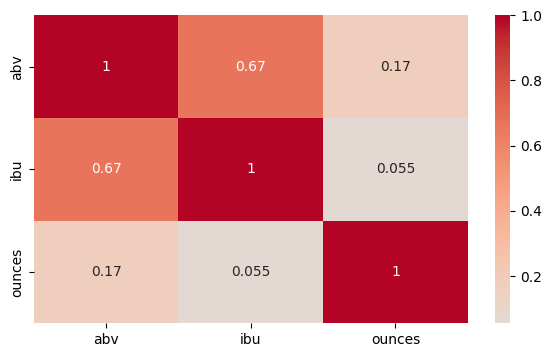

In [60]:
# Mediante un diagrama de pares, podemos ver la realción (correlación)
# Solo analizamos las numéricas, quito id porque es un numérico, pero no nos aporta nada
plt.figure(figsize=(7, 4))

sns.heatmap(beer[['abv','ibu','ounces']].corr(), annot = True, cmap = 'coolwarm',center = 0)
plt.show()

# No sé si he hecho algo mal, pero no hay nada significativo en los gráficos, no parece que haya ninguna relación entre las variables

## Ejercicio 13
Representa el nivel de alcohol (columna `abv`) en un histograma. ¿Se trata de una distribución simétrica o asimétrica?

<Axes: >

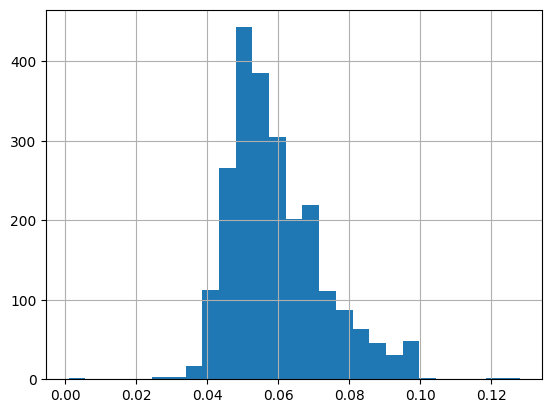

In [61]:
beer['abv'].hist(bins=27)

# Es un poquito simétrico, pero se dispersa más a la derecha

## Ejercicio 14
Representa mediante un *boxplot* de `seaborn` la variable `abv`

<Axes: ylabel='abv'>

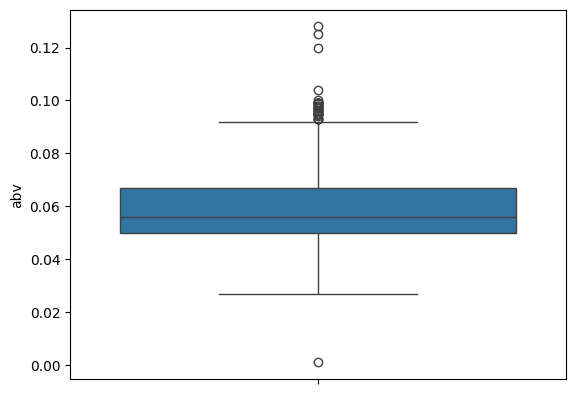

In [62]:
sns.boxplot(beer['abv'])

## Ejercicio 15
1. ¿Qué estilos son los que tienen en media más alcohol?
2. ¿Y los estilos que son en media más amargos?

In [63]:
# 1 Agrupamos por estilo y ostramos en orden de cantidad alcohol
beer.groupby('style')[['abv']].mean().sort_values('abv',ascending=False)

,abv
style,
English Barleywine,0.107667
Quadrupel (Quad),0.104000
American Barleywine,0.099000
American Malt Liquor,0.099000
Russian Imperial Stout,0.097636
...,...
Berliner Weissbier,0.043909
English Dark Mild Ale,0.041500
Light Lager,0.040417


In [64]:
# 2 Agrupamos por estilo y ostramos en orden de amargor
beer.groupby('style')[['ibu']].mean().sort_values('ibu', ascending=False)

,ibu
style,
American Barleywine,96.00
American Double / Imperial IPA,93.32
Russian Imperial Stout,86.50
American Double / Imperial Pilsner,85.00
Belgian Strong Dark Ale,72.00
...,...
Kristalweizen,NaN
Low Alcohol Beer,NaN
Mead,NaN


## Ejercicio 16
Carga el datasets de cervecerias `datasets_breweries.csv`

In [65]:
brew = pd.read_csv('.\data\datasets_breweries.csv') # Ruta lógica desde donde se encuentra el beerset
brew

,Unnamed: 0,name,city,state
0,0,NorthGate Brewing,Minneapolis,MN
1,1,Against the Grain Brewery,Louisville,KY
2,2,Jack's Abby Craft Lagers,Framingham,MA
3,3,Mike Hess Brewing Company,San Diego,CA
4,4,Fort Point Beer Company,San Francisco,CA
...,...,...,...,...
553,553,Covington Brewhouse,Covington,LA
554,554,Dave's Brewfarm,Wilson,WI
555,555,Ukiah Brewing Company,Ukiah,CA
556,556,Butternuts Beer and Ale,Garrattsville,NY


## Ejercicio 17
1. Renombra la columna `Unnamed: 0` como `brewery_id`
2. Renombra también la columna `name` por `brewery_name`. ¿Puedes hacer ambos apartados en una sola sentencia?

In [66]:
brew.rename(columns={'Unnamed: 0':'brewery_id'}, inplace=True)
brew

,brewery_id,name,city,state
0,0,NorthGate Brewing,Minneapolis,MN
1,1,Against the Grain Brewery,Louisville,KY
2,2,Jack's Abby Craft Lagers,Framingham,MA
3,3,Mike Hess Brewing Company,San Diego,CA
4,4,Fort Point Beer Company,San Francisco,CA
...,...,...,...,...
553,553,Covington Brewhouse,Covington,LA
554,554,Dave's Brewfarm,Wilson,WI
555,555,Ukiah Brewing Company,Ukiah,CA
556,556,Butternuts Beer and Ale,Garrattsville,NY


## Ejercicio 18
Junta los dos datasets que tienes

In [67]:
beer_brew = pd.merge(beer, brew, on='brewery_id', suffixes=["_beer", "_brewery"])
beer_brew

,abv,ibu,id,name_beer,style,brewery_id,ounces,name_brewery,city,state
0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0,10 Barrel Brewing Company,Bend,OR
1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0,18th Street Brewery,Gary,IN
2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0,18th Street Brewery,Gary,IN
3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0,18th Street Brewery,Gary,IN
4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0,18th Street Brewery,Gary,IN
...,...,...,...,...,...,...,...,...,...,...
2405,0.067,45.0,928,Belgorado,Belgian IPA,424,12.0,Wynkoop Brewing Company,Denver,CO
2406,0.052,NaN,807,Rail Yard Ale,American Amber / Red Ale,424,12.0,Wynkoop Brewing Company,Denver,CO
2407,0.055,NaN,620,B3K Black Lager,Schwarzbier,424,12.0,Wynkoop Brewing Company,Denver,CO
2408,0.055,40.0,145,Silverback Pale Ale,American Pale Ale (APA),424,12.0,Wynkoop Brewing Company,Denver,CO


## Ejercicio 19
1. ¿Cuántos estados diferentes hay?
2. ¿Y ciudades diferentes?
3. ¿Cuántas cervecerías hay?

In [68]:
# Estados
beer_brew.groupby('state')['state'].nunique().count()

np.int64(51)

In [69]:
# Ciudades
beer_brew.groupby('city')['city'].nunique().count()

np.int64(384)

In [70]:
# Cervecerías
beer_brew.groupby('name_brewery')['name_brewery'].nunique().count()

np.int64(551)

In [71]:
# Coincide con las cervecerías diferentes que hay en el segundo dataset
brew.nunique()

brewery_id    558
name          551
city          384
state          51
dtype: int64

In [73]:
beer_brew[beer_brew['name_brewery'].duplicated()][['name_brewery']].unique()

AttributeError: 'DataFrame' object has no attribute 'unique'

## Ejercicio 20
Agrupa por estado y ciudad, la media, mediana y máximo nivel de alcohol

In [48]:
beer_brew.groupby(['state','city'])['abv'].agg(['mean','median','max'])

mean  median    max
state city                               
AK    Anchorage   0.054200  0.0520  0.063
      Juneau      0.053000  0.0530  0.053
      Soldotna    0.058500  0.0580  0.068
      Talkeetna   0.059500  0.0585  0.065
AL    Birmingham  0.065400  0.0600  0.093
...                    ...     ...    ...
WI    Wilson      0.055000  0.0550  0.055
WV    Lewisburg   0.062000  0.0620  0.067
WY    Jackson     0.054857  0.0520  0.068
      Pinedale    0.061000  0.0610  0.072
      Sheridan    0.052833  0.0480  0.070

[401 rows x 3 columns]

## Ejercicio 21
¿Cuáles son las cervezas más amargas que se consumen en Indiana, estado = `IN`?

In [72]:
beer_brew[beer_brew['state'] == 'IN'][['ibu']].sort_values('ibu',ascending=False)
# No sale nada, aunque debería. Eso me hace pensar que aunque 
# visualizamos 'IN' en el estado, no es eso lo que tiene guardado

,ibu


In [ ]:
# Comprobamos qué contienen esas celdas
list(beer_brew['state'])
beer_brew['state'].unique()
# Hay un espacio tramposo delante de los estados

<StringArray>
[' OR', ' IN', ' CA', ' FL', ' MO', ' WA', ' CO', ' LA', ' KY', ' AK', ' WI',
 ' OH', ' OK', ' NC', ' MI', ' TX', ' CT', ' AL', ' MA', ' AZ', ' MN', ' ME',
 ' VA', ' IL', ' TN', ' MT', ' WY', ' NE', ' NY', ' UT', ' NJ', ' PA', ' NV',
 ' SC', ' GA', ' RI', ' IA', ' AR', ' ID', ' SD', ' DC', ' KS', ' ND', ' VT',
 ' MD', ' WV', ' HI', ' DE', ' NM', ' MS', ' NH']
Length: 51, dtype: str

In [75]:
beer_brew['state'] = beer_brew['state'].str.strip()
# Comprobamos que ahora está bien
list(beer_brew['state'])
beer_brew['state'].unique()

<StringArray>
['OR', 'IN', 'CA', 'FL', 'MO', 'WA', 'CO', 'LA', 'KY', 'AK', 'WI', 'OH', 'OK',
 'NC', 'MI', 'TX', 'CT', 'AL', 'MA', 'AZ', 'MN', 'ME', 'VA', 'IL', 'TN', 'MT',
 'WY', 'NE', 'NY', 'UT', 'NJ', 'PA', 'NV', 'SC', 'GA', 'RI', 'IA', 'AR', 'ID',
 'SD', 'DC', 'KS', 'ND', 'VT', 'MD', 'WV', 'HI', 'DE', 'NM', 'MS', 'NH']
Length: 51, dtype: str

In [81]:
# Volvemos a calcular
beer_brew[beer_brew['state'] == 'IN'][['ibu']].sort_values('ibu',ascending=False)

,ibu
479,115.0
2191,115.0
811,104.0
2062,91.0
2189,90.0
...,...
2056,NaN
2061,NaN
2190,NaN
2277,NaN


## Ejercicio 22
Obtén una tabla con los principales estadísticos del campo `ibu`,  a nivel ciudad

In [ ]:
# Agrupamos por ciudad y vemos estadísticos
beer_brew.groupby('city').describe()

abv                                                       \
               count      mean       std    min      25%     50%      75%   
city                                                                        
Abingdon         1.0  0.059000       NaN  0.059  0.05900  0.0590  0.05900   
Abita Springs    3.0  0.050667  0.012503  0.042  0.04350  0.0450  0.05500   
Ada              1.0  0.069000       NaN  0.069  0.06900  0.0690  0.06900   
Afton            4.0  0.059000  0.004899  0.053  0.05750  0.0590  0.06050   
Airway Heights   5.0  0.051600  0.010668  0.041  0.04200  0.0530  0.05500   
...              ...       ...       ...    ...      ...     ...      ...   
Woodinville      4.0  0.063250  0.003500  0.058  0.06325  0.0650  0.06500   
Worcester        1.0  0.065000       NaN  0.065  0.06500  0.0650  0.06500   
Yakima           2.0  0.056000  0.016971  0.044  0.05000  0.0560  0.06200   
Yardley          1.0  0.052000       NaN  0.052  0.05200  0.0520  0.05200   
York             4.0  0.058000  0.005354  0.052  0.05575  0.0575  0.05975   

                        ibu              ... brewery_id        ounces        \
                  max count        mean  ...        75%    max  count  mean   
city                                     ...                                  
Abingdon        0.059   1.0  135.000000  ...      344.0  344.0    1.0  12.0   
Abita Springs   0.065   3.0   27.333333  ...      533.0  533.0    3.0  12.0   
Ada             0.069   0.0         NaN  ...      137.0  137.0    1.0  16.0   
Afton           0.065   4.0   43.000000  ...      382.0  382.0    4.0  12.0   
Airway Heights  0.067   0.0         NaN  ...      390.0  390.0    5.0  16.0   
...               ...   ...         ...  ...        ...    ...    ...   ...   
Woodinville     0.065   4.0   46.750000  ...      487.0  487.0    4.0  14.0   
Worcester       0.065   1.0   69.000000  ...      339.0  339.0    1.0  16.0   
Yakima          0.068   2.0   54.000000  ...      483.0  483.0    2.0  12.0   
Yardley         0.052   0.0         NaN  ...      113.0  113.0    1.0  12.0   
York            0.065   4.0   44.250000  ...      298.0  298.0    4.0  12.0   

                                                        
                     std   min   25%   50%   75%   max  
city                                                    
Abingdon             NaN  12.0  12.0  12.0  12.0  12.0  
Abita Springs   0.000000  12.0  12.0  12.0  12.0  12.0  
Ada                  NaN  16.0  16.0  16.0  16.0  16.0  
Afton           0.000000  12.0  12.0  12.0  12.0  12.0  
Airway Heights  0.000000  16.0  16.0  16.0  16.0  16.0  
...                  ...   ...   ...   ...   ...   ...  
Woodinville     2.309401  12.0  12.0  14.0  16.0  16.0  
Worcester            NaN  16.0  16.0  16.0  16.0  16.0  
Yakima          0.000000  12.0  12.0  12.0  12.0  12.0  
Yardley              NaN  12.0  12.0  12.0  12.0  12.0  
York            0.000000  12.0  12.0  12.0  12.0  12.0  

[384 rows x 40 columns]

## Ejercicio 23
Consigue en un DataFrame de todas las cervezas en cuyas cervecerías al menos haya una cerveza con un `abv` mínimo 0.07.

In [76]:
# Sacamos a una lista las cervecerías con un abv mayor de 0.07
breweries_007 = beer_brew['name_brewery'][beer_brew['abv'] >= 0.07].unique()

# Mostramos cervezas de la cervecerías de esa lista
beer_brew[beer_brew['name_brewery'].isin(breweries_007)]

,abv,ibu,id,name_beer,style,brewery_id,ounces,name_brewery,city,state
1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0,18th Street Brewery,Gary,IN
2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0,18th Street Brewery,Gary,IN
3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0,18th Street Brewery,Gary,IN
4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0,18th Street Brewery,Gary,IN
5,0.077,NaN,2261,Black Exodus,Oatmeal Stout,177,12.0,18th Street Brewery,Gary,IN
...,...,...,...,...,...,...,...,...,...,...
2405,0.067,45.0,928,Belgorado,Belgian IPA,424,12.0,Wynkoop Brewing Company,Denver,CO
2406,0.052,NaN,807,Rail Yard Ale,American Amber / Red Ale,424,12.0,Wynkoop Brewing Company,Denver,CO
2407,0.055,NaN,620,B3K Black Lager,Schwarzbier,424,12.0,Wynkoop Brewing Company,Denver,CO
2408,0.055,40.0,145,Silverback Pale Ale,American Pale Ale (APA),424,12.0,Wynkoop Brewing Company,Denver,CO


## Ejercicio 24
Teniendo en cuenta la media de amargor de todas las cervezas, obtén una tabla con las cervezas cuyos estados tengan una media de amargor en cerveza por encima de la media

In [ ]:
# Sacamos a una lista de estados con media de amargor mayor a la media
estados_plus = beer_brew['state'][beer_brew['ibu'] >= beer_brew['ibu'].mean()].unique()

# Mostramos cervezas de esos estados
beer_brew.loc[beer_brew['state'].isin(estados_plus)]

,abv,ibu,id,name_beer,style,brewery_id,ounces,name_brewery,city,state
0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0,10 Barrel Brewing Company,Bend,OR
1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0,18th Street Brewery,Gary,IN
2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0,18th Street Brewery,Gary,IN
3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0,18th Street Brewery,Gary,IN
4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0,18th Street Brewery,Gary,IN
...,...,...,...,...,...,...,...,...,...,...
2405,0.067,45.0,928,Belgorado,Belgian IPA,424,12.0,Wynkoop Brewing Company,Denver,CO
2406,0.052,NaN,807,Rail Yard Ale,American Amber / Red Ale,424,12.0,Wynkoop Brewing Company,Denver,CO
2407,0.055,NaN,620,B3K Black Lager,Schwarzbier,424,12.0,Wynkoop Brewing Company,Denver,CO
2408,0.055,40.0,145,Silverback Pale Ale,American Pale Ale (APA),424,12.0,Wynkoop Brewing Company,Denver,CO
